In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from helper_functions import *
from algorithms import *
import random
from pathlib import Path

In [4]:
BASE_DIR = './'
DIR_24   =  "./chromosomes"
IMG_24   =  f"{DIR_24}"
IMG_24 = Path('/Users/aning/Downloads/chromosomes')
SUBSET_SIZE = 100
all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))  

In [5]:
print(IMG_24)

/Users/aning/Downloads/chromosomes


In [6]:
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24

In [9]:
len(img_24)

100

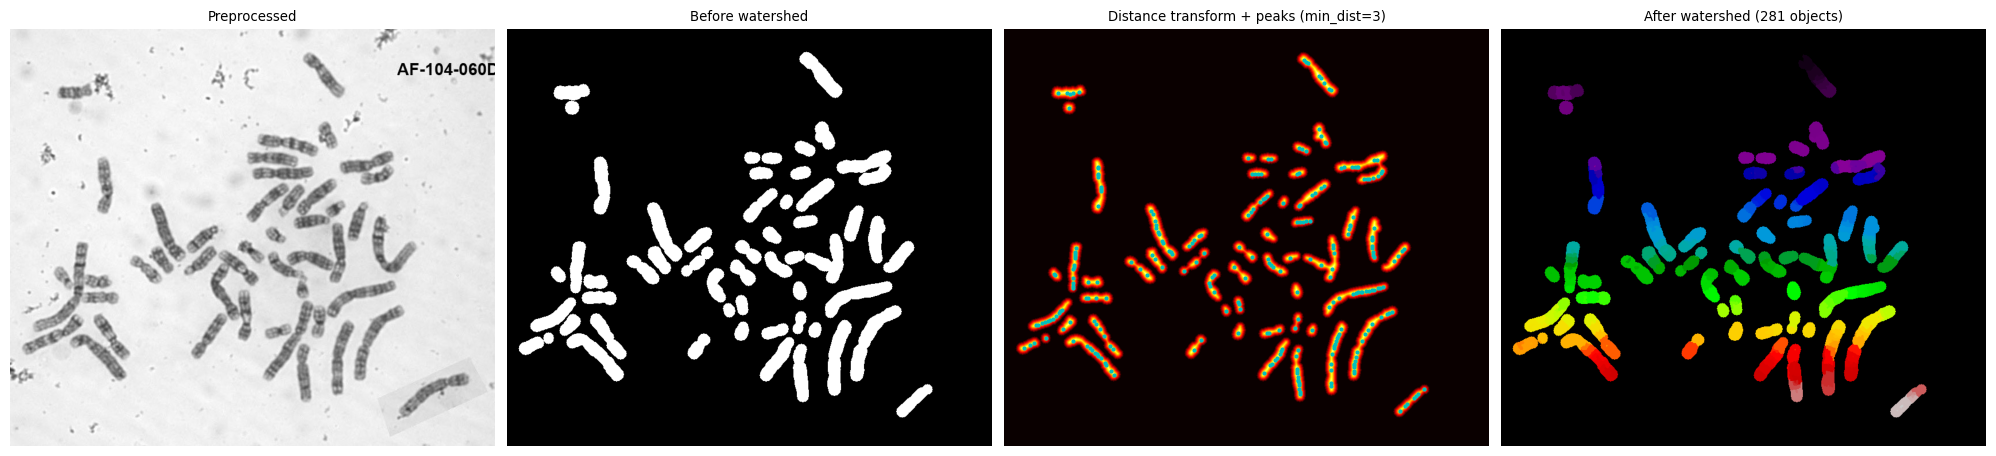

Number of chromosomes detected: 43


In [18]:
img = skimage.io.imread(img_24[18])
mask = chromosome_mask_with_adaptive_histogram(img_24[56],closing_disk_size=4,   # reduce from 8
        opening_disk_size=9,   # reduce from 8
        min_distance=3,        # reduce to split closer chromosomes
        min_object_size=400, plot=True)

labels = label(mask)
print(f"Number of chromosomes detected: {labels.max()}")

In [9]:
chromosome_data = []
for img_path in img_24[:10]:
    mask = chromosome_mask_with_adaptive_histogram(img_path, plot=False)
    labels = label(mask)
    chromosome_data.append({
        "img_name":img_path.name,
        "chromosome_count":labels.max(),
        "mask":mask,
        "needs_fix":labels.max()<40
    })


chromosome_data = pd.DataFrame(chromosome_data)

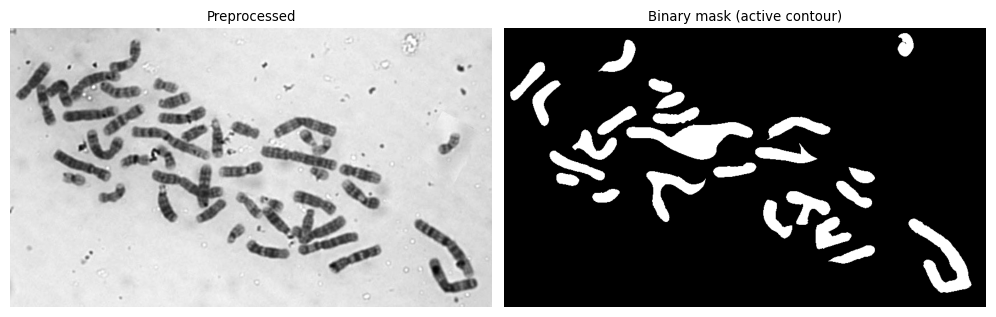

In [19]:
mask = chromosome_mask_with_active_contour(img_24[5], plot=True)

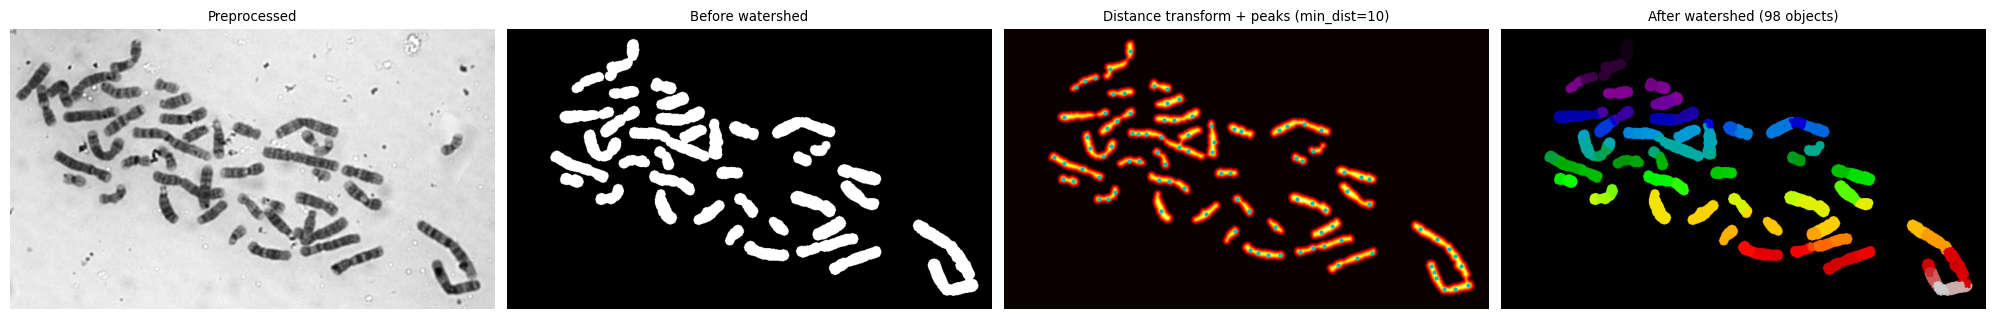

In [20]:
mask = chromosome_mask_with_adaptive_histogram(img_24[5],plot=True)

In [ ]:
from algorithms import classify_denver_groups,extract_centromere_and_bands,extract_chromosome_features

abnormal_img = Path('/Users/aning/Downloads/chromosomes')
sorted_abnormal_images = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))  

all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG")) 
df = extract_chromosome_features(img_24[:10], method='adaptive_histogram', plot=False)
df_clean = df[df['solidity'] > 0.8]
df = extract_centromere_and_bands(df_clean, plot=False)
df_classified = classify_denver_groups(df)

In [14]:
df_classified.head()

,image_name,chromosome_label,chrom_img,method,area,length,width,eccentricity,centroid_row,centroid_col,...,bbox_maxc,number_of_chromosomes,solidity,centromere_position,n_bands,centromeric_index,centromeric_index_area,centromere_type,relative_length,denver_group
0,1051681.jpg,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,2141.0,62.469298,55.423545,0.461361,45.774404,361.318543,...,392,25,0.833723,63,6,-0.008495,0.046707,acrocentric,4.567097,D
1,1051681.jpg,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,1106.0,67.483535,21.864370,0.946059,90.774864,446.409584,...,474,25,0.892655,38,5,0.436900,0.301989,metacentric,4.933685,C
2,1051681.jpg,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,923.0,54.310236,22.538811,0.909821,105.386782,238.388949,...,265,25,0.899610,30,5,0.447618,0.000000,metacentric,3.970592,C
3,1051681.jpg,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,1274.0,74.607641,22.134907,0.954976,138.927786,181.379121,...,194,25,0.930606,21,5,0.281473,0.175824,submetacentric,5.454524,C
5,1051681.jpg,6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,895.0,60.751888,19.795009,0.945427,177.536313,409.036872,...,431,25,0.885262,29,5,0.477351,0.460335,metacentric,4.441538,C
